In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyRegressor
import time

In [2]:
# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [3]:
# Data Loading
def load_data(train_path: str, test_path: str):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

In [4]:
# Data Splitting (Features / Target / IDs)
def split_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    test_ids = test_df["Id"].copy()

    train_df = train_df.drop("Id", axis=1)
    test_df = test_df.drop("Id", axis=1)

    y = train_df["SalePrice"].copy()
    X = train_df.drop("SalePrice", axis=1).copy()

    return X, y, test_df, test_ids

In [5]:
# Dataset Shape Information
def get_dataset_shapes(train_df: pd.DataFrame, test_df: pd.DataFrame):
    return train_df.shape, test_df.shape

In [6]:
# Feature Type Identification (Numeric / Categorical)
def get_feature_type_counts(X: pd.DataFrame):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

    return {
        "numeric_count": len(numeric_features),
        "categorical_count": len(categorical_features),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features
    }


In [7]:

# Utility Function (Currency Formatting)
def format_currency(value):
    return f"${value:,.2f}"


In [8]:
# Target Variable Summary (SalePrice Analysis)
def get_target_summary(y: pd.Series):
    return {
        "mean": format_currency(y.mean()),
        "median": format_currency(y.median()),
        "std": format_currency(y.std()),
        "skewness": f"{y.skew():.4f}",
        "min": format_currency(y.min()),
        "max": format_currency(y.max())
    }

In [9]:
# Missing Values Analysis (Top Features)
def get_top_missing_columns(X: pd.DataFrame, top_n: int = 10):
    missing_counts = X.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    missing_percent = (X.isnull().mean() * 100)
    missing_percent = missing_percent[missing_percent > 0]

    missing_table = pd.DataFrame({
        "missing_count": missing_counts,
        "missing_percent": missing_percent[missing_counts.index]
    })

    return missing_table.head(top_n)


In [10]:

# Visualization (Target Distribution)
def plot_target_distribution(y: pd.Series):
    plt.figure(figsize=(8, 5))
    plt.hist(y, bins=50)
    plt.title("SalePrice Distribution")
    plt.xlabel("SalePrice")
    plt.ylabel("Frequency")
    plt.show()

In [11]:
# Initial Exploratory Data Analysis (EDA)
def run_initial_eda(train_df: pd.DataFrame, test_df: pd.DataFrame, X: pd.DataFrame, y: pd.Series):
    train_shape, test_shape = get_dataset_shapes(train_df, test_df)
    feature_info = get_feature_type_counts(X)
    target_summary = get_target_summary(y)
    top_missing = get_top_missing_columns(X)

    print("Train shape:", train_shape)
    print("Test shape:", test_shape)

    print("\nTarget Summary (SalePrice):")
    for key, value in target_summary.items():
        print(f"{key}: {value}")

    print("\nFeature Type Counts:")
    print("Numeric features:", feature_info["numeric_count"])
    print("Categorical features:", feature_info["categorical_count"])

    print("\nTop 10 Columns by Missingness:")
    print(top_missing)

In [12]:
# Target Insight (Skewness Interpretation)
def print_target_insight(y: pd.Series):
    skew = y.skew()

    if skew > 1:
        print("\nInsight: Strong positive skew → consider log transformation (RMSLE justified)")
    elif skew > 0.5:
        print("\nInsight: Moderate skew → log transformation may help")
    else:
        print("\nInsight: Low skew → transformation likely unnecessary")


In [13]:
# Feature Grouping for Preprocessing
def get_feature_groups(X: pd.DataFrame):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    return numeric_features, categorical_features


In [14]:
# Preprocessing Pipeline (Imputation + Encoding)
def create_preprocessor(X: pd.DataFrame):
    numeric_features, categorical_features = get_feature_groups(X)

    # Numeric pipeline
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # Categorical pipeline
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Combine
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features)
        ]
    )

    return preprocessor

In [15]:
# Target Transformation (Log for RMSLE)
def transform_target(y: pd.Series):
    return np.log1p(y)


In [16]:
# RMSLE Scorer (via RMSE on log target)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

In [17]:
# Dummy Regressor Baseline
def evaluate_dummy(X, y, preprocessor):

    y_log = transform_target(y)

    model = DummyRegressor(strategy="mean")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    scores = cross_val_score(
        pipeline,
        X,
        y_log,
        cv=5,
        scoring=rmse_scorer
    )

    runtime = time.time() - start_time

    return {
        "rmse_mean": -scores.mean(),
        "rmse_std": scores.std(),
        "runtime_sec": runtime
    }

In [18]:
# Linear Regression Baseline
def evaluate_linear_regression(X, y, preprocessor):

    y_log = transform_target(y)

    model = LinearRegression()

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    scores = cross_val_score(
        pipeline,
        X,
        y_log,
        cv=5,
        scoring=rmse_scorer
    )

    runtime = time.time() - start_time

    return {
        "rmse_mean": -scores.mean(),
        "rmse_std": scores.std(),
        "runtime_sec": runtime
    }

In [19]:
# RMSE (for log target)
def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [20]:
# Decision Tree Depth Analysis
def evaluate_decision_tree_depth(X, y, preprocessor, depths, min_samples_leaf=5):

    y_log = transform_target(y)

    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    train_scores = []
    cv_scores = []

    for depth in depths:

        model = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=min_samples_leaf,
            random_state=0
        )

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        fold_train_rmse = []
        fold_val_rmse = []

        for train_idx, val_idx in kf.split(X):

            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

            pipeline.fit(X_train, y_train)

            # Train prediction
            y_train_pred = pipeline.predict(X_train)
            train_rmse = compute_rmse(y_train, y_train_pred)

            # Validation prediction
            y_val_pred = pipeline.predict(X_val)
            val_rmse = compute_rmse(y_val, y_val_pred)

            fold_train_rmse.append(train_rmse)
            fold_val_rmse.append(val_rmse)

        train_scores.append(np.mean(fold_train_rmse))
        cv_scores.append(np.mean(fold_val_rmse))

    return train_scores, cv_scores

In [21]:
# Plot Depth vs Performance
def plot_tree_performance(depths, train_scores, cv_scores):

    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_scores, marker='o', label="Train RMSE")
    plt.plot(depths, cv_scores, marker='o', label="CV RMSE")

    plt.xlabel("Max Depth")
    plt.ylabel("RMSE (log scale)")
    plt.title("Decision Tree: Depth vs Performance")
    plt.legend()
    plt.grid()

    plt.show()

In [22]:
# Random Forest Evaluation
def evaluate_random_forest(X, y, preprocessor, n_estimators_list):

    y_log = transform_target(y)

    results = []

    for n in n_estimators_list:

        model = RandomForestRegressor(
            n_estimators=n,
            random_state=0,
            n_jobs=-1
        )

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        start_time = time.time()

        scores = cross_val_score(
            pipeline,
            X,
            y_log,
            cv=5,
            scoring=rmse_scorer
        )

        runtime = time.time() - start_time

        results.append({
            "n_estimators": n,
            "rmse_mean": -scores.mean(),
            "rmse_std": scores.std(),
            "runtime_sec": runtime
        })

    return pd.DataFrame(results)

In [23]:
# Gradient Boosting Evaluation
def evaluate_gradient_boosting(X, y, preprocessor, param_grid):

    y_log = transform_target(y)

    results = []

    for lr in param_grid["learning_rate"]:
        for n in param_grid["n_estimators"]:

            model = GradientBoostingRegressor(
                learning_rate=lr,
                n_estimators=n,
                max_depth=3,
                random_state=0
            )

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            start_time = time.time()

            scores = cross_val_score(
                pipeline,
                X,
                y_log,
                cv=5,
                scoring=rmse_scorer
            )

            runtime = time.time() - start_time

            results.append({
                "learning_rate": lr,
                "n_estimators": n,
                "rmse_mean": -scores.mean(),
                "rmse_std": scores.std(),
                "runtime_sec": runtime
            })

    return pd.DataFrame(results)

In [24]:
# Plot RF Performance
def plot_rf_performance(results_df):

    plt.figure(figsize=(8,5))

    plt.plot(results_df["n_estimators"], results_df["rmse_mean"], marker='o')

    plt.xlabel("Number of Trees")
    plt.ylabel("RMSE (log scale)")
    plt.title("Random Forest Performance")
    plt.grid()

    plt.show()

In [25]:
# Plot Learning Rate vs Performance
def plot_gb_results(results_df):

    plt.figure(figsize=(8,5))

    for lr in results_df["learning_rate"].unique():
        subset = results_df[results_df["learning_rate"] == lr]

        plt.plot(
            subset["n_estimators"],
            subset["rmse_mean"],
            marker='o',
            label=f"lr={lr}"
        )

    plt.xlabel("Number of Trees")
    plt.ylabel("RMSE (log scale)")
    plt.title("Gradient Boosting: Learning Rate Trade-off")
    plt.legend()
    plt.grid()

    plt.show()

In [26]:
# XGBoost Evaluation
def evaluate_xgboost(X, y, preprocessor, param_grid):

    y_log = transform_target(y)

    results = []

    for lr in param_grid["learning_rate"]:
        for n in param_grid["n_estimators"]:

            model = XGBRegressor(
                learning_rate=lr,
                n_estimators=n,
                tree_method="hist",
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=0,
                n_jobs=-1
            )

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            start_time = time.time()

            scores = cross_val_score(
                pipeline,
                X,
                y_log,
                cv=5,
                scoring=rmse_scorer
            )

            runtime = time.time() - start_time

            results.append({
                "learning_rate": lr,
                "n_estimators": n,
                "rmse_mean": -scores.mean(),
                "rmse_std": scores.std(),
                "runtime_sec": runtime
            })

    return pd.DataFrame(results)

In [27]:
# Final Model Training & Submission
def create_submission(X, y, X_test, test_ids, preprocessor):

    y_log = transform_target(y)

    # best model (από GB)
    model = GradientBoostingRegressor(
        learning_rate=0.1,
        n_estimators=300,
        max_depth=3,
        random_state=0
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # TRAIN ΣΕ ΟΛΟ ΤΟ DATASET
    pipeline.fit(X, y_log)

    # PREDICT (σε log scale)
    preds_log = pipeline.predict(X_test)

    # inverse transform (ΠΟΛΥ ΣΗΜΑΝΤΙΚΟ)
    preds = np.expm1(preds_log)
    preds = np.round(preds, 2)

    # submission dataframe
    submission = pd.DataFrame({
        "Id": test_ids,
        "SalePrice": preds
    })

    return submission

In [28]:
# Permutation Feature Importance
def plot_feature_importance(X, y, preprocessor):

    y_log = transform_target(y)

    model = GradientBoostingRegressor(
        learning_rate=0.1,
        n_estimators=300,
        max_depth=3,
        random_state=0
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X, y_log)

    result = permutation_importance(
        pipeline,
        X,
        y_log,
        n_repeats=5,
        random_state=0,
        n_jobs=-1
    )

    importances = result.importances_mean

    # παίρνουμε feature names μετά το encoding
    feature_names = X.columns

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    top10 = importance_df.head(10)

    plt.figure(figsize=(8, 5))
    plt.barh(top10["feature"], top10["importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 10 Feature Importances (Permutation)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    return top10

In [29]:
# Residual Analysis
def plot_residuals(X, y, preprocessor):

    y_log = transform_target(y)

    model = GradientBoostingRegressor(
        learning_rate=0.1,
        n_estimators=300,
        max_depth=3,
        random_state=0
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X, y_log)

    y_pred = pipeline.predict(X)

    residuals = y_log - y_pred

    plt.figure(figsize=(8,5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0)

    plt.xlabel("Predicted (log price)")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Predictions")

    plt.show()

In [30]:
# Plot XGBoost Performance
def plot_xgb_results(results_df):

    plt.figure(figsize=(8,5))

    for lr in results_df["learning_rate"].unique():
        subset = results_df[results_df["learning_rate"] == lr]

        plt.plot(
            subset["n_estimators"],
            subset["rmse_mean"],
            marker='o',
            label=f"lr={lr}"
        )

    plt.xlabel("Number of Trees")
    plt.ylabel("RMSE (log scale)")
    plt.title("XGBoost: Learning Rate Trade-off")
    plt.legend()
    plt.grid()

    plt.show()

In [31]:
# Final Decision Tree Evaluation
def evaluate_decision_tree(X, y, preprocessor, max_depth=6, min_samples_leaf=5):

    y_log = transform_target(y)

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=0
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    scores = cross_val_score(
        pipeline,
        X,
        y_log,
        cv=5,
        scoring=rmse_scorer
    )

    runtime = time.time() - start_time

    return {
        "rmse_mean": -scores.mean(),
        "rmse_std": scores.std(),
        "runtime_sec": runtime
    }

Train shape: (1460, 81)
Test shape: (1459, 80)

Target Summary (SalePrice):
mean: $180,921.20
median: $163,000.00
std: $79,442.50
skewness: 1.8829
min: $34,900.00
max: $755,000.00

Feature Type Counts:
Numeric features: 36
Categorical features: 43

Top 10 Columns by Missingness:
              missing_count  missing_percent
PoolQC                 1453        99.520548
MiscFeature            1406        96.301370
Alley                  1369        93.767123
Fence                  1179        80.753425
MasVnrType              872        59.726027
FireplaceQu             690        47.260274
LotFrontage             259        17.739726
GarageType               81         5.547945
GarageYrBlt              81         5.547945
GarageFinish             81         5.547945


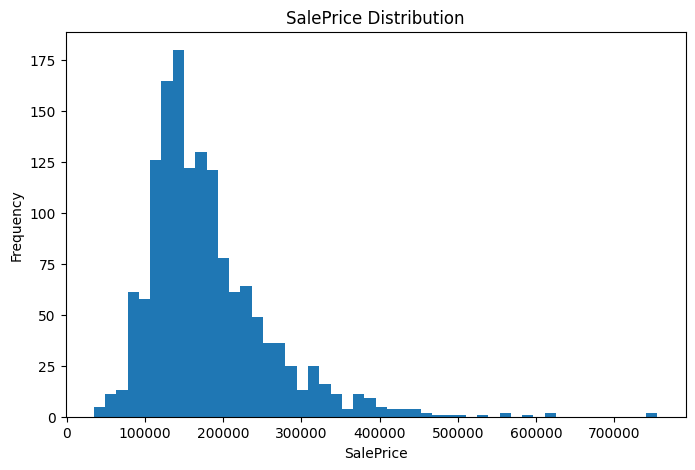


Insight: Strong positive skew → consider log transformation (RMSLE justified)

=== Baseline Results (RMSLE) ===
Dummy Regressor: 0.3992 (+/- 0.0159) | Runtime: 0.41 sec
Linear Regression: 0.1460 (+/- 0.0224) | Runtime: 0.95 sec
Decision Tree: 0.1940 (+/- 0.0105) | Runtime: 0.74 sec


In [32]:

train_path = "data/train.csv"
test_path = "data/test.csv"

train_df, test_df = load_data(train_path, test_path)
X, y, test_features, test_ids = split_data(train_df, test_df)

run_initial_eda(train_df, test_df, X, y)
plot_target_distribution(y)
print_target_insight(y)

preprocessor = create_preprocessor(X)

dummy_results = evaluate_dummy(X, y, preprocessor)
lr_results = evaluate_linear_regression(X, y, preprocessor)
dt_results = evaluate_decision_tree(X, y, preprocessor, max_depth=6, min_samples_leaf=5)

print("\n=== Baseline Results (RMSLE) ===")
print(
    f"Dummy Regressor: {dummy_results['rmse_mean']:.4f} "
    f"(+/- {dummy_results['rmse_std']:.4f}) | "
    f"Runtime: {dummy_results['runtime_sec']:.2f} sec"
)

print(
    f"Linear Regression: {lr_results['rmse_mean']:.4f} "
    f"(+/- {lr_results['rmse_std']:.4f}) | "
    f"Runtime: {lr_results['runtime_sec']:.2f} sec"
)

print(
    f"Decision Tree: {dt_results['rmse_mean']:.4f} "
    f"(+/- {dt_results['rmse_std']:.4f}) | "
    f"Runtime: {dt_results['runtime_sec']:.2f} sec"
)

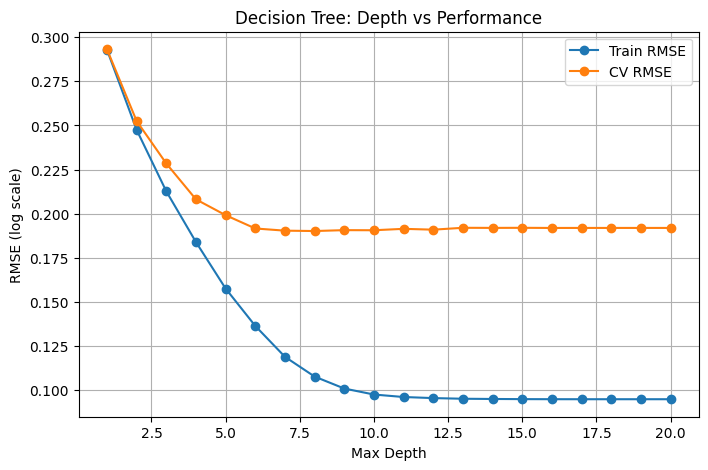


=== Random Forest Results ===
   n_estimators  rmse_mean  rmse_std  runtime_sec
0            50   0.144800  0.009119     6.811162
1           100   0.144370  0.009493    11.432109
2           200   0.143271  0.009732    20.890147
3           300   0.143025  0.009729    29.525287


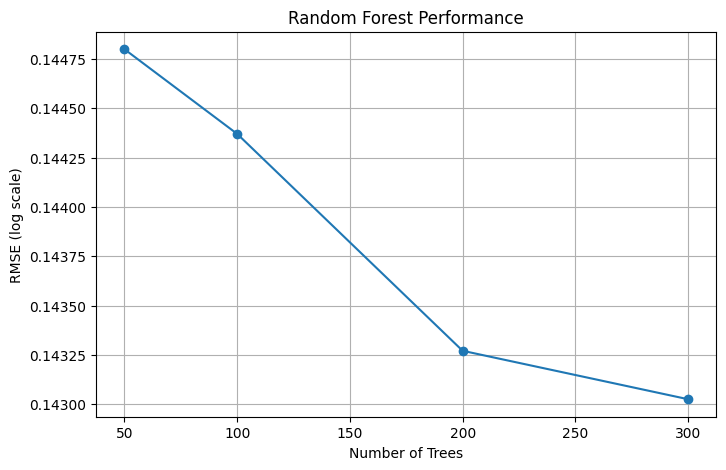

In [33]:
depths = list(range(1, 21))

train_scores, cv_scores = evaluate_decision_tree_depth(
    X, y, preprocessor, depths
)

plot_tree_performance(depths, train_scores, cv_scores)

n_estimators_list = [50, 100, 200, 300]

rf_results = evaluate_random_forest(
    X, y, preprocessor, n_estimators_list
)

print("\n=== Random Forest Results ===")
print(rf_results)

plot_rf_performance(rf_results)


=== Gradient Boosting Results ===
   learning_rate  n_estimators  rmse_mean  rmse_std  runtime_sec
0           0.01           100   0.232013  0.011710    10.979173
1           0.01           300   0.148852  0.008085    29.946170
2           0.01           600   0.130887  0.008488    57.679631
3           0.05           100   0.134862  0.008697    10.680734
4           0.05           300   0.124109  0.010103    28.350050
5           0.05           600   0.123402  0.010588    53.624609
6           0.10           100   0.126323  0.008319     9.748190
7           0.10           300   0.122989  0.008343    27.398748
8           0.10           600   0.123310  0.008700    54.645109


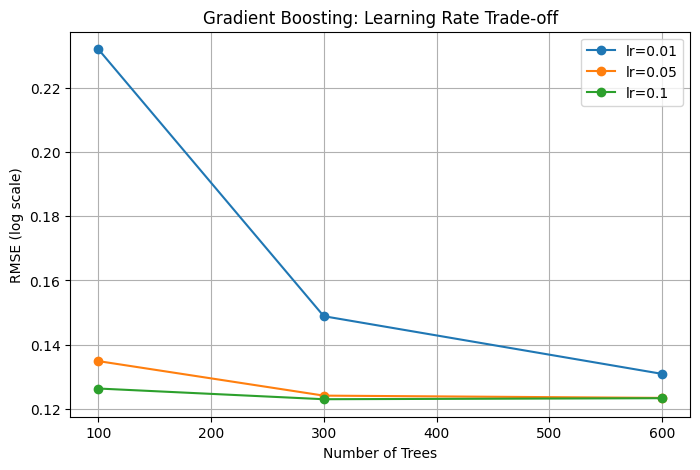

In [34]:
gb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 600]
}

gb_results = evaluate_gradient_boosting(
    X, y, preprocessor, gb_param_grid
)

print("\n=== Gradient Boosting Results ===")
print(gb_results)

plot_gb_results(gb_results)


=== XGBoost Results ===
   learning_rate  n_estimators  rmse_mean  rmse_std  runtime_sec
0           0.01           100   0.215109  0.012300     2.552793
1           0.01           300   0.139683  0.010691     6.042084
2           0.01           600   0.128877  0.010916    11.068579
3           0.05           100   0.133802  0.011098     2.369877
4           0.05           300   0.130456  0.011239     5.572389
5           0.05           600   0.130488  0.011316     9.973664
6           0.10           100   0.130611  0.012709     2.224517
7           0.10           300   0.130255  0.013283     5.394551
8           0.10           600   0.130252  0.013355     9.536071


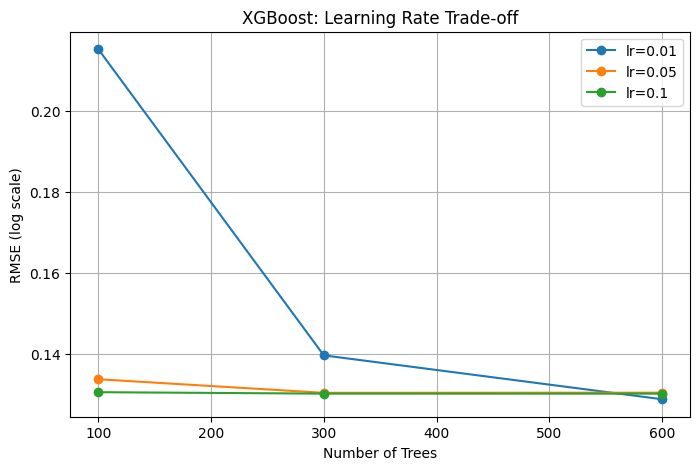

In [35]:
xgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 600]
}

xgb_results = evaluate_xgboost(
    X, y, preprocessor, xgb_param_grid
)

print("\n=== XGBoost Results ===")
print(xgb_results)

plot_xgb_results(xgb_results)


=== Top 10 Permutation Importances ===


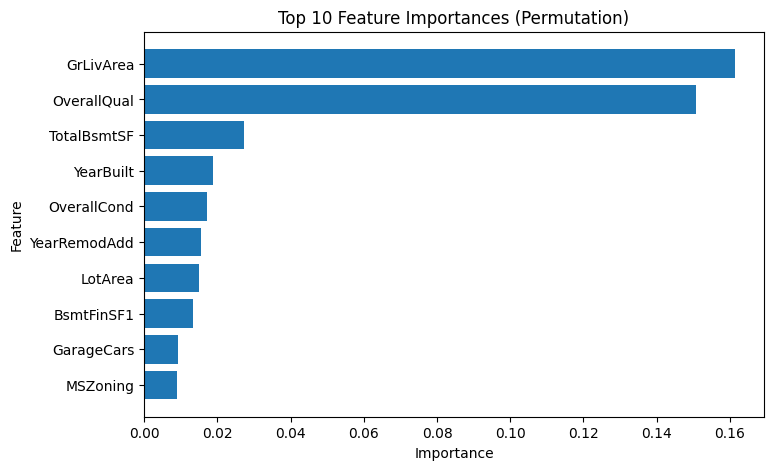

         feature  importance
45     GrLivArea    0.161233
16   OverallQual    0.150701
37   TotalBsmtSF    0.027422
18     YearBuilt    0.018766
17   OverallCond    0.017164
19  YearRemodAdd    0.015539
3        LotArea    0.014889
33    BsmtFinSF1    0.013291
60    GarageCars    0.009407
1       MSZoning    0.009099


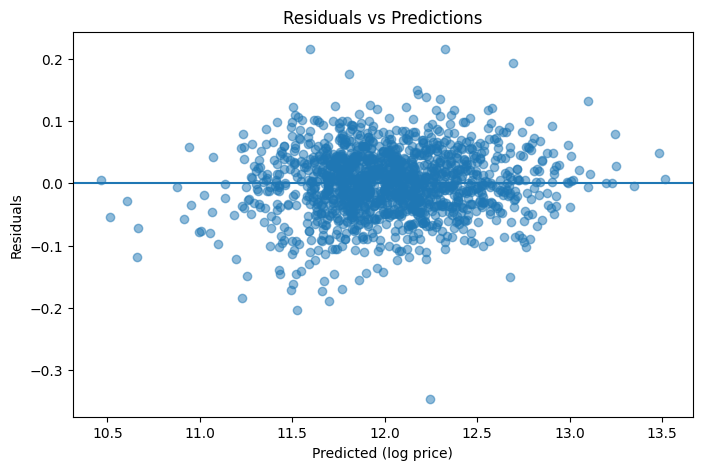

In [36]:
print("\n=== Top 10 Permutation Importances ===")
top10_importances = plot_feature_importance(X, y, preprocessor)
print(top10_importances)

plot_residuals(X, y, preprocessor)

In [37]:
submission = create_submission(X, y, test_features, test_ids, preprocessor)
submission.to_csv("submission.csv", index=False, float_format="%.2f")

print("\nSubmission file created!")

print("\nSubmission Preview:")
print(submission.head())

print("\nSubmission Summary:")
print(submission.describe())


Submission file created!

Submission Preview:
     Id  SalePrice
0  1461  120150.88
1  1462  155264.30
2  1463  185957.26
3  1464  189859.71
4  1465  187240.07

Submission Summary:
                Id      SalePrice
count  1459.000000    1459.000000
mean   2190.000000  177365.522543
std     421.321334   76080.759714
min    1461.000000   41495.620000
25%    1825.500000  127857.345000
50%    2190.000000  157064.590000
75%    2554.500000  209388.580000
max    2919.000000  584231.440000


In [38]:
comparison_df = pd.DataFrame({
    "Model": [
        "Dummy",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "RMSE": [
        dummy_results["rmse_mean"],
        lr_results["rmse_mean"],
        dt_results["rmse_mean"],
        rf_results.loc[rf_results["n_estimators"] == 200, "rmse_mean"].values[0],
        gb_results.loc[
            (gb_results["learning_rate"] == 0.10) & (gb_results["n_estimators"] == 300),
            "rmse_mean"
        ].values[0],
        xgb_results.loc[
            (xgb_results["learning_rate"] == 0.01) & (xgb_results["n_estimators"] == 600),
            "rmse_mean"
        ].values[0]
    ],
    "Std": [
        dummy_results["rmse_std"],
        lr_results["rmse_std"],
        dt_results["rmse_std"],
        rf_results.loc[rf_results["n_estimators"] == 200, "rmse_std"].values[0],
        gb_results.loc[
            (gb_results["learning_rate"] == 0.10) & (gb_results["n_estimators"] == 300),
            "rmse_std"
        ].values[0],
        xgb_results.loc[
            (xgb_results["learning_rate"] == 0.01) & (xgb_results["n_estimators"] == 600),
            "rmse_std"
        ].values[0]
    ],
    "Runtime_sec": [
        dummy_results["runtime_sec"],
        lr_results["runtime_sec"],
        dt_results["runtime_sec"],
        rf_results.loc[rf_results["n_estimators"] == 200, "runtime_sec"].values[0],
        gb_results.loc[
            (gb_results["learning_rate"] == 0.10) & (gb_results["n_estimators"] == 300),
            "runtime_sec"
        ].values[0],
        xgb_results.loc[
            (xgb_results["learning_rate"] == 0.01) & (xgb_results["n_estimators"] == 600),
            "runtime_sec"
        ].values[0]
    ]
})

comparison_df["RMSE"] = comparison_df["RMSE"].round(4)
comparison_df["Std"] = comparison_df["Std"].round(4)
comparison_df["Runtime_sec"] = comparison_df["Runtime_sec"].round(2)
print(comparison_df)

               Model    RMSE     Std  Runtime_sec
0              Dummy  0.3992  0.0159         0.41
1  Linear Regression  0.1460  0.0224         0.95
2      Decision Tree  0.1940  0.0105         0.74
3      Random Forest  0.1433  0.0097        20.89
4  Gradient Boosting  0.1230  0.0083        27.40
5            XGBoost  0.1289  0.0109        11.07
